# Portfolio optimization

We consider the problem of choosing a *long term* stock portfolio, given a set of stocks and their price over some period under *risk aversion parameter* $\gamma \gt 0$.

Assume there are $m$ stocks to be considered.
The *portfolio* will be represented by a column vector $w \in \mathbb{R}^m$, such that $\sum_{i = 1}^{m} w_i = 1$. If $w_i \gt 0$, you use a fraction $w_i$ of your total money to *buy* the $i$'th stock, while $w_i \lt 0$ represent *<a href="https://en.wikipedia.org/wiki/Short_(finance)">shorting</a>* that stock. In both cases we assume the stock is bought/shorted for the entire period.

Let $p_{j,i}$ represent the price of the $i$'th stock at time step $j$. If there are $n+1$ time steps, then $p \in \mathbb{R}^{(n+1) \times m}$ is a matrix.

We let $r \in \mathbb{R}^{n \times m}$ be the matrix, where $r_{j,i}$ represents the fractional reward of stock $i$ at time step $j$, i.e., $r_{j,i} = \frac{p_{j+1,i} - p_{j,i}}{p_{j,i}}$ for $1 \leq j \leq n$.

By $r_j$ we denote the $j$‘th row of $r$, viewed as a _column vector_ $(r_{j,1},\ldots, r_{j,m})$.

We make the (unrealistic) assumptation that we can model $r$ model a *Random Variable*, distributed as a multivariate Gaussian with *estimated* means, 

$$ 
\mu=\mathbb{E} \big[ r \big] \simeq \frac{1}{n} \sum_{j=1}^n r_{j} 
$$ 

and *estimated covariance matrix*,

$$ 
\Sigma=\mathbb{E} \big[ (r- \mu)(r - \mu)^T \big] \simeq \frac{1}{n} \sum_{j=1}^n \big[ (r_j- \mu)(r_j - \mu)^T \big]. 
$$

Note that $\mu_i$ and $\Sigma_{i,i}$ are the estimated mean and variance for stock $i$.

The distribution of *returns* using some *w* is then

$$
R_w = \mathcal{N}(\mu_w, \sigma_w^2), \quad \mu_w = w^T\mu, \quad \sigma_w^2 = w^T \Sigma w. 
$$

Now, we want to *maximize* for a balance between high return $\mu_w$ and low risk $\sigma_w^2$. This leads to the following optimization problem,
where we want to find the value $w^*$ of $w$ maximizing the following expresion:

$$
w^* = \arg\max_w \bigg[ w^T\mu - \gamma w^T \Sigma w \bigg] 
$$

$$ 
\text{subject to} \sum_{i=1}^m w_i = 1, 
$$

where $\gamma$ controls the balance between *risk* and *return*. A high value of $\gamma$ indicate we are willing to take *low* risk and vise versa.

In this project you should find $w^*$ for different values of $\gamma$ using real stock values of your choice. 
The project consists of the following three questions.

1. We need a module for collecting stock values, for this we will use the Python modyle `yfinance` that connects to Yahoo! Finance's API. See [https://pypi.org/project/yfinance/](https://pypi.org/project/yfinance/) for a description of how to install and use the module. Using this you should write a function `get_prices([stocks, ... ], start, end, interval)`, that returns a tuple, `(stocks, prices)`. Where `prices[i, j]` represent the **opening** price of stock $j$ at time step $i$ and `stocks[j]` is the name of the $j$'th stock. Save the fetched data to a file, such that when requesting the same data again, the data is be loaded from the file instead of using the API (e.g., save a pandas dataframe as a csv file).

2. Plot the loaded price data. Each stock should be labeled with its name (for example `MSFT` or `GOOGL`). You should use at least 5 stocks. The legend should be ordered by the last price fetched for each stock. Plot both the raw stock prices and stocks normalized to all start with price 1.0.

3. Calculate $r$, $\mu$ and $\Sigma$ using the formulas above and the $p$ you calculated at (1). Plot the probability density function (*pdf*) of each stock. (**Hint**: The method `norm.pdf` from the module `scipy.stats` might become convenient. Note that it takes the mean and the standard deviation as arguments.)

4. Solve the optimization problem defined above for different values of $\gamma$, e.g., `gammas = numpy.linspace(1.0, 2.8, 10)` and plot the *pdf* of each solution to a single plot with appropriate legends. Finally, create a scatter plot of how $w^*$ changes as $\gamma$ changes.
For each value of $\gamma$ plot the fraction of each stock in the portfolio.

In [7]:
import yfinance
import scipy
import matplotlib.pyplot as plt
import numpy
import pandas
import os

Loading data from MSFT.GOOGL.AAPL.AMZN.META.ZM-2025-01-01-2025-12-31-1d.csv


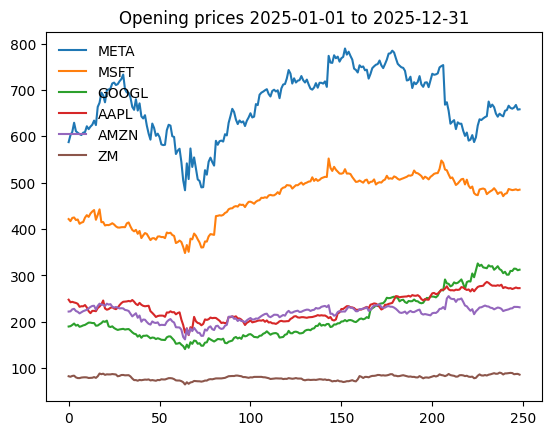

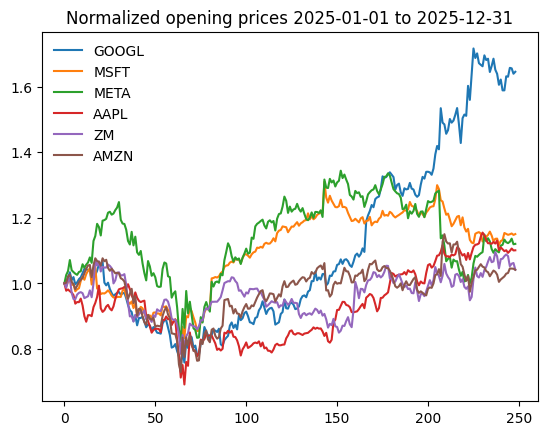

In [8]:
# SOLUTION TO 1

def print_stock_info(stocks):
    '''Print information from the Yahoo! finance API for a list of stocks.'''
    tickers = yfinance.Tickers(' '.join(stocks))
    for stock in stocks:
        print(tickers.tickers[stock].info)

def get_prices(stocks, start, end, interval):
    '''Get (list of stock names, opening prices) from Yahoo! finance (or cached file).'''

    file = f'{".".join(stocks)}-{start}-{end}-{interval}.csv'
    
    if os.path.isfile(file):
        print(f'Loading data from {file}')
        df = pandas.read_csv(file)
    else:
        df = yfinance.download(stocks, start=start, end=end, interval=interval)
        df = df['Open']
        print(f'Saving data to {file}')
        df.to_csv(file, index=False)

    return list(df.columns), df.to_numpy()

def normalize_prices(prices):
    '''Normalize prices so that all prices start at 1.0.'''

    return prices / prices[0]

# SOLUTION TO 2

def plot_prices(stocks, prices, title=None):
    '''Plot list of stock prices.'''

    data = list(zip(stocks, prices.T))
    data = sorted(data, key=lambda x: -x[1][-1])
    for name, price in data:
        plt.plot(price, label=name)
    if title:
        plt.title(title)
    plt.legend(frameon=False)
    plt.show()

stocks = ['MSFT', 'GOOGL', 'AAPL', 'AMZN', 'META', 'ZM']
#print_stock_info(stocks)
start = '2025-01-01'
end = '2025-12-31'
stocks, prices = get_prices(stocks, start=start, end=end, interval='1d')
plot_prices(stocks, prices, title=f'Opening prices {start} to {end}')
prices = normalize_prices(prices)
plot_prices(stocks, prices, title=f'Normalized opening prices {start} to {end}')

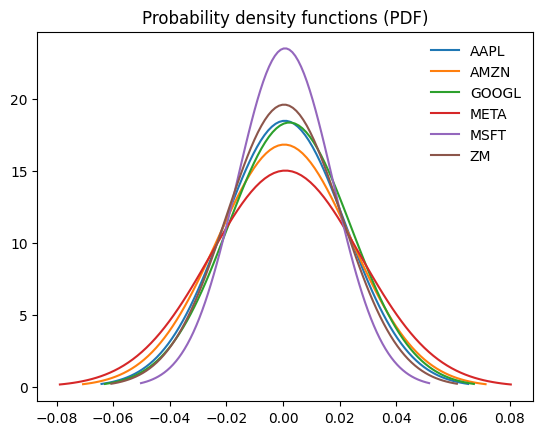

In [9]:
# SOLUTION TO 3

#r = ((prices - numpy.roll(prices, 1, axis=0)) / prices)[1:]  # Original solution
r = ((numpy.roll(prices, -1, axis=0) - prices) / prices)[:-1]  # roll = -1 = next, solution stated in text...
means = r.mean(axis=0)
rows, columns = r.shape
sigma = sum(numpy.outer(r_ - means, r_ - means) for r_ in r) / rows

for m, s, stock in zip(means, sigma.diagonal(), stocks):
    x = numpy.linspace(m - 3 * s ** 0.5, m + 3 * s ** 0.5, 100)
    plt.plot(x, scipy.stats.norm.pdf(x, loc=m, scale=s ** 0.5), label=stock)
    
plt.title('Probability density functions (PDF)')
plt.legend(frameon=False)
plt.show()

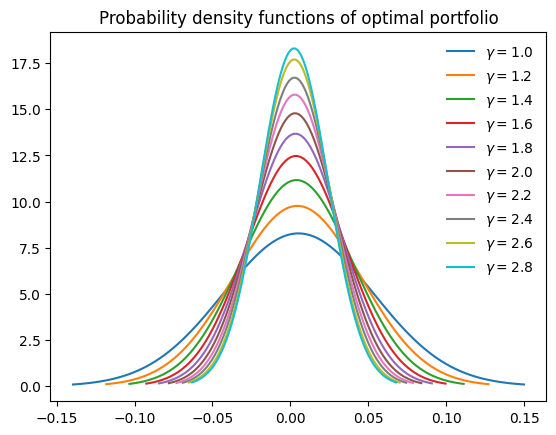

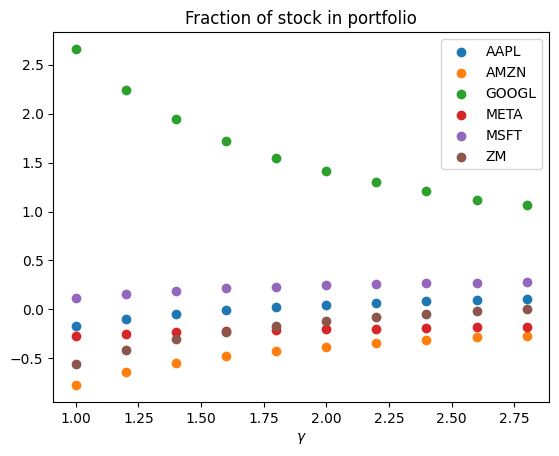

In [12]:
# SOLUTION TO 4

gammas = numpy.linspace(1.0, 2.8, 10)

def get_dist(x):
    m = x.T @ means
    s = x.T @ sigma @ x
    x_ = numpy.linspace(m - 3 * s ** 0.5, m + 3 * s ** 0.5, 100)
    return x_, scipy.stats.norm.pdf(x_, m, s ** 0.5)

def objective_fun(gamma):
    def objective(w):
        return -(w.T @ means - gamma * w.T @ sigma @ w)
    return objective

solutions = numpy.array(
    [
        scipy.optimize.minimize(
            objective_fun(gamma),
            numpy.full(len(stocks), 1/len(stocks)),
            constraints={'type': 'eq', 'fun': lambda w: sum(w) - 1},
          #  method='Nelder-Mead'
        ).x
        for gamma in gammas
    ]
)

for gamma, solution in zip(gammas, solutions):
    plt.plot(*get_dist(solution), label=f'$\\gamma = {gamma:.5}$')
plt.legend(frameon=False)
plt.title('Probability density functions of optimal portfolio')
plt.show()

for stock, solution in zip(stocks, solutions.T):
    plt.scatter(gammas, solution, label=stock)
plt.legend()
plt.title('Fraction of stock in portfolio')
plt.xlabel(r'$\gamma$')
plt.show()